# EDA — Statistical Audit pandas-dev/pandas

**Research Questions:**
1. Berapa probabilitas sebuah PR di-merge?
2. Apakah rata-rata bug report per bulan berubah setelah rilis pandas 2.0?
3. Berapa probabilitas sebuah issue membutuhkan lebih dari 30 hari untuk ditutup?


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_issues = pd.read_csv("../data/clean/issues_clean.csv")
df_prs = pd.read_csv("../data/clean/prs_clean.csv")

print("Issues:", df_issues.shape)
print("PRs:", df_prs.shape)
df_issues.head()

Issues: (1000, 10)
PRs: (1000, 11)


,number,title,state,created_at,closed_at,comments,author_association,labels,duration_days,month_year
0,63521,BUG: comparison of categoricals with NA,closed,2025-12-31 11:01:37+00:00,2025-12-31 14:15:16+00:00,2,NONE,"[{'id': 76811, 'node_id': 'MDU6TGFiZWw3NjgxMQ=...",0,2025-12
1,63489,ENH: drop function should take kwarg rows,closed,2025-12-26 23:06:58+00:00,2025-12-27 13:15:38+00:00,2,NONE,"[{'id': 76812, 'node_id': 'MDU6TGFiZWw3NjgxMg=...",0,2025-12
2,63437,BUG: 3.0.0rc1 sdist fails tests with `--no-str...,closed,2025-12-20 08:01:21+00:00,2025-12-20 20:27:20+00:00,3,CONTRIBUTOR,"[{'id': 76811, 'node_id': 'MDU6TGFiZWw3NjgxMQ=...",0,2025-12
3,63430,BLD: Windows nightlies are missing from scient...,closed,2025-12-19 11:28:59+00:00,2025-12-19 18:04:19+00:00,3,CONTRIBUTOR,"[{'id': 48070600, 'node_id': 'MDU6TGFiZWw0ODA3...",0,2025-12
4,63428,DOC: Add Chinese version of README (README_zh.md),closed,2025-12-19 06:01:33+00:00,2025-12-20 16:12:42+00:00,5,CONTRIBUTOR,"[{'id': 134699, 'node_id': 'MDU6TGFiZWwxMzQ2OT...",1,2025-12


## Overview 

Dataset yang digunakan terdiri dari 1.000 data issue dan 1.000 data pull request (PR) dari repository pandas-dev/pandas di GitHub.

Berdasarkan data awal yang ditampilkan, issue berasal dari berbagai kategori seperti bug, enhancement, build, dan documentation. Seluruh issue yang diambil memiliki status closed, sehingga data dapat digunakan untuk analisis durasi penyelesaian issue.

Kolom author_association menunjukkan bahwa issue dan PR berasal dari beberapa jenis pengguna, mulai dari pengguna umum hingga kontributor aktif proyek. Selain itu, jumlah komentar pada issue cukup bervariasi, yang menandakan adanya interaksi dan diskusi selama proses penyelesaian issue berlangsung.

Data juga memiliki informasi waktu seperti created_at dan closed_at, sehingga memungkinkan dilakukan analisis terhadap durasi penutupan issue maupun pull request pada tahap berikutnya.

In [13]:
print("=== ISSUES ===")
print(df_issues[['duration_days', 'comments']].describe())

print("\n=== PRs ===")
print(df_prs[['duration_days', 'is_merged']].describe())

=== ISSUES ===
       duration_days     comments
count    1000.000000  1000.000000
mean      463.967000     5.682000
std       692.306525     8.417585
min         0.000000     0.000000
25%         3.000000     2.000000
50%        87.000000     3.000000
75%       692.000000     7.000000
max      3043.000000   168.000000

=== PRs ===
       duration_days    is_merged
count    1000.000000  1000.000000
mean        8.513000     0.633000
std        17.251709     0.482228
min         0.000000     0.000000
25%         0.000000     0.000000
50%         1.000000     1.000000
75%         7.000000     1.000000
max       121.000000     1.000000


## Statistik Deskriptif

Issues

Berdasarkan hasil analisis, rata-rata durasi penutupan issue mencapai 463 hari. Namun median durasinya hanya 87 hari, sehingga terlihat bahwa ada beberapa issue lama yang membuat nilai rata-rata menjadi tinggi.

Issue paling cepat dapat diselesaikan dalam waktu 0 hari, sedangkan yang paling lama mencapai 3043 hari. Selain itu, rata-rata jumlah komentar pada setiap issue sekitar 5.6 komentar, dengan jumlah komentar terbanyak mencapai 168 komentar.

Pull Request (PR)

Untuk pull request, rata-rata waktu penyelesaiannya sekitar 8.5 hari, sehingga proses PR cenderung lebih cepat dibandingkan issue.

Nilai rata-rata pada kolom is_merged sebesar 0.633 menunjukkan bahwa sekitar 63.3% PR berhasil di-merge ke repository. Nilai median is_merged yang bernilai 1 juga menunjukkan bahwa lebih dari setengah pull request yang masuk berhasil diterima.

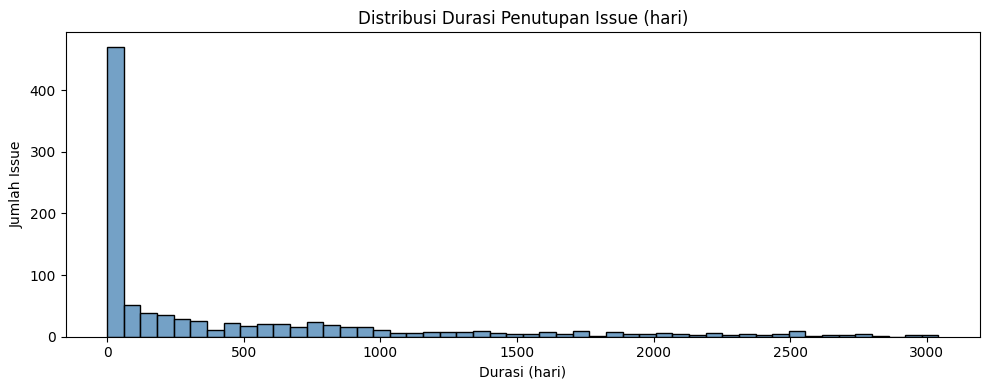

In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(df_issues['duration_days'].dropna(), bins=50, color='steelblue')
plt.title('Distribusi Durasi Penutupan Issue (hari)')
plt.xlabel('Durasi (hari)')
plt.ylabel('Jumlah Issue')
plt.tight_layout()
plt.savefig('../data/clean/plot_durasi_issue.png')
plt.show()

## Distribusi Durasi Penutupan Issue 

Berdasarkan grafik histogram, terlihat bahwa sebagian besar issue dapat diselesaikan dalam waktu kurang dari 100 hari. Hal ini terlihat dari tingginya jumlah data pada bagian awal grafik.

Meski begitu, terdapat beberapa issue yang membutuhkan waktu sangat lama untuk ditutup, bahkan mencapai lebih dari 3000 hari. Walaupun jumlahnya tidak banyak, issue tersebut cukup memengaruhi persebaran data secara keseluruhan.

Distribusi data juga terlihat tidak seimbang karena grafik lebih menumpuk di sisi kiri dan memanjang ke kanan. Kondisi ini menunjukkan adanya outlier atau data dengan durasi penutupan yang jauh lebih tinggi dibandingkan sebagian besar issue lainnya.

Hasil ini sesuai dengan statistik deskriptif sebelumnya, di mana nilai rata-rata durasi issue lebih tinggi dibandingkan median. Perbedaan tersebut terjadi karena adanya beberapa issue lama yang membuat nilai rata-rata meningkat cukup besar.

Secara keseluruhan, mayoritas issue pada repository dapat ditangani dalam waktu yang relatif cepat. Namun, masih terdapat sejumlah kecil issue lama yang belum terselesaikan dalam waktu panjang.

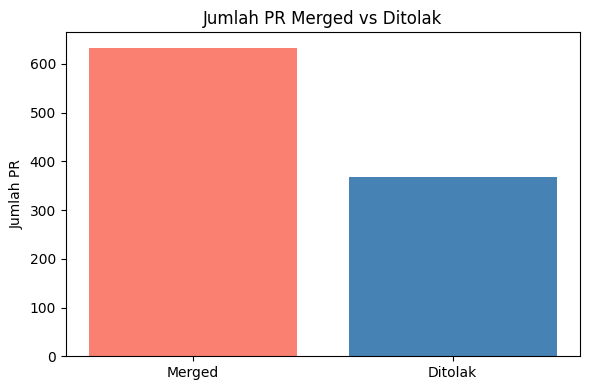

In [15]:
merged_counts = df_prs['is_merged'].value_counts()
labels = ['Merged', 'Ditolak']
plt.figure(figsize=(6, 4))
plt.bar(labels, merged_counts.values, color=['salmon', 'steelblue'])
plt.title('Jumlah PR Merged vs Ditolak')
plt.ylabel('Jumlah PR')
plt.tight_layout()
plt.savefig('../data/clean/plot_pr_merged.png')
plt.show()

## Jumlah PR Merged vs Ditolak

Berdasarkan grafik, jumlah PR yang berhasil di-merge lebih banyak dibandingkan PR yang tidak di-merge.

Dari total 1.000 data PR:

633 PR berhasil di-merge
367 PR tidak berhasil di-merge

Hasil tersebut menunjukkan bahwa lebih dari setengah PR pada repository pandas-dev/pandas berhasil diterima. Persentase merge yang cukup tinggi ini menunjukkan bahwa banyak kontribusi yang dapat masuk ke dalam repository.

Data is_merged ini nantinya digunakan pada tahap analisis berikutnya untuk menghitung probabilitas keberhasilan merge menggunakan metode Bernoulli MLE.

C:\Users\Amila Zahira\AppData\Local\Temp\ipykernel_23004\4121497753.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_issues['month_year'] = pd.to_datetime(df_issues['created_at']).dt.to_period('M')


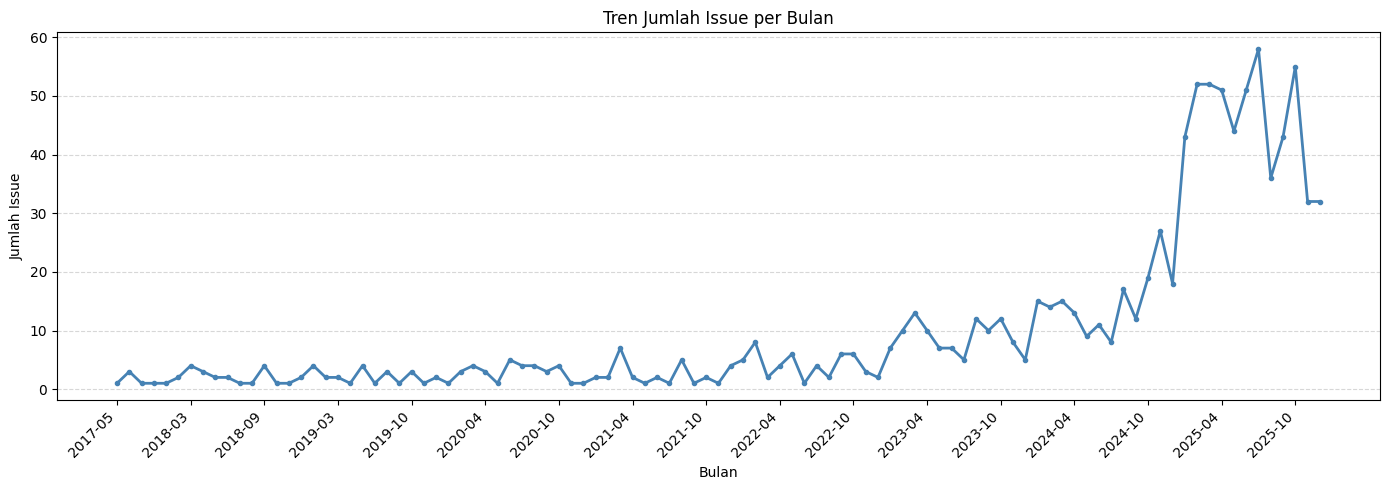

In [17]:
df_issues['month_year'] = pd.to_datetime(df_issues['created_at']).dt.to_period('M')
monthly = df_issues.groupby('month_year').size()

plt.figure(figsize=(14, 5))
plt.plot(range(len(monthly)), monthly.values, color='steelblue', linewidth=2, marker='o', markersize=3)

# Tampilkan label setiap 6 bulan
step = 6
tick_positions = range(0, len(monthly), step)
tick_labels = [str(monthly.index[i]) for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')
plt.title('Tren Jumlah Issue per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Issue')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/clean/plot_issue_bulanan.png')
plt.show()

## Tren Jumlah Issue per Bulan

Berdasarkan grafik garis yang diperoleh, jumlah issue mengalami peningkatan dari tahun ke tahun.

Pada periode 2017 hingga 2022, jumlah issue per bulan masih relatif sedikit dan cenderung stabil. Memasuki tahun 2023, jumlah issue mulai meningkat secara bertahap.

Peningkatan paling terlihat terjadi pada tahun 2024 sampai 2025. Pada periode tersebut, jumlah issue per bulan naik cukup signifikan dan mencapai titik tertinggi sekitar 57 issue.

Di bagian akhir tahun 2025, jumlah issue terlihat sedikit menurun dibanding beberapa bulan sebelumnya. Meskipun begitu, jumlahnya masih lebih tinggi dibanding periode awal pada dataset.

Secara keseluruhan, grafik ini menunjukkan bahwa aktivitas issue pada repository pandas-dev/pandas semakin meningkat dalam beberapa tahun terakhir.